In [1]:
from autoreduce import *
import numpy as np

# SEIRVD Population Model

The standard SIR model is expanded into an SEIRVD model to represent more stages of disease transmission. The model includes susceptible, exposed, infected, recovered, vaccinated, and deceased populations.


## Model Definition

The six state variables are:

$
S=\text{Susceptible},\quad
E=\text{Exposed},\quad
I=\text{Infected},\quad
R=\text{Recovered},\quad
V=\text{Vaccinated},\quad
D=\text{Dead}
$


The state vector is:

$
\begin{aligned}
x &=
\begin{bmatrix}
S \\
E \\
I \\
R \\
V \\
D
\end{bmatrix}
\end{aligned}
$

The parameter vector is:

$
\begin{aligned}
\Theta &=
\begin{bmatrix}
\beta \\
\sigma \\
\gamma \\
\nu \\
\mu \\
N
\end{bmatrix}
\end{aligned}
$

The SEIRVD system is defined by:

$
\begin{aligned}
\dot{S} &= -\frac{\beta S I}{N} - \nu S \\
\dot{E} &= \frac{\beta S I}{N} - \sigma E \\
\dot{I} &= \sigma E - \gamma I - \mu I \\
\dot{R} &= \gamma I \\
\dot{V} &= \nu S \\
\dot{D} &= \mu I
\end{aligned}
$

The infected population is initially selected as the model output:

$
\begin{aligned}
y &= I
\end{aligned}
$



In [2]:
from autoreduce import *
import numpy as np
import matplotlib.pyplot as plt

# SEIRVD population model
n = 6
nouts = 1

# States:
# x[0] = S, Susceptible
# x[1] = E, Exposed
# x[2] = I, Infected
# x[3] = R, Recovered
# x[4] = V, Vaccinated
# x[5] = D, Dead

# Parameters:
# P[0] = beta   infection/transmission rate
# P[1] = sigma  exposed -> infected rate
# P[2] = gamma  recovery rate
# P[3] = nu     vaccination rate
# P[4] = mu     mortality/death rate
# P[5] = N      total population

P = np.zeros(6)

P[0] = 0.35     # beta
P[1] = 0.20     # sigma
P[2] = 0.10     # gamma
P[3] = 0.01     # nu
P[4] = 0.005    # mu
P[5] = 1000     # N

params_values = P.copy()
timepoints_ode = np.linspace(0, 150, 100)

x_init = np.zeros(n)
x_init[0] = 990   # S
x_init[1] = 9     # E
x_init[2] = 1     # I
x_init[3] = 0     # R
x_init[4] = 0     # V
x_init[5] = 0     # D

error_tol = 100
nstates_tol = 2

x, f, P = load_ODE_model(n, len(params_values))
params = P

# SEIRVD ODEs
f[0] = -P[0] * x[0] * x[2] / P[5] - P[3] * x[0]

f[1] = P[0] * x[0] * x[2] / P[5] - P[1] * x[1]

f[2] = P[1] * x[1] - P[2] * x[2] - P[4] * x[2]

f[3] = P[2] * x[2]

f[4] = P[3] * x[0]

f[5] = P[4] * x[2]

# Output: infected population I
C = np.zeros((nouts, len(x)), dtype=int)
C[0][2] = 1
C = C.tolist()

sys = System(
    x,
    f,
    params=params,
    C=C,
    params_values=params_values,
    x_init=x_init
)


## AutoReduce Setup

The model contains six state variables, so `n = 6`. The output matrix selects $x_2$, which represents the infected population. AutoReduce uses this output to evaluate the accuracy of each reduced model.


In [3]:
sys.x


[x0, x1, x2, x3, x4, x5]

In [4]:
try:
    import seaborn as sn
    for j in range(nouts):
        sn.heatmap(out_Ss[:,:,j].T)
        plt.xlabel('Time')
        plt.ylabel('Parameters')
        plt.title('Sensitivity of output[{0}] with respect to all parameters'.format(j))
        plt.show()
except:
    print('Plotting libraries missing.')


Plotting libraries missing.


## Model Reduction

AutoReduce tests different combinations of retained states and generates the possible reduced models. Some combinations may fail when the eliminated variables cannot be solved using time-scale separation.


In [5]:
from autoreduce.utils import get_reducible
timepoints_ssm = np.linspace(0,60,10)
timepoints_ode = np.linspace(0, 100, 100)
sys_reduce = get_reducible(sys, timepoints_ode, timepoints_ssm)
#results = sys_reduce.reduce_simple(skip_numerical_computation = True,skip_error_computation = True, skip_robustness_computation = True)
results = sys_reduce.reduce_simple()


Could not find solution for: x3 from P2*x2
Could not find solution for: x4 from 0
Could not find solution for: x5 from P4*x2
Successful solution obtained with states: [x2]!


C:\Users\angel\autoreduce\autoreduce\model_reduction.py:1229: UserWarning: Solve time-scale separation failed. Check model consistency.
  warnings.warn(
C:\Users\angel\autoreduce\autoreduce\model_reduction.py:1215: UserWarning: Solve time-scale separation failed. Check model consistency.
  warnings.warn(


SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
Could not find solution for: x3 from P2*x2
Could not find solution for: x4 from P3*x0
Could not find solution for: x5 from P4*x2
Successful solution obtained with states: [x0, x2]!
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
Could not find solution for: x3 from P2*x2
Could not find solution for: x4 from 0
Could not find solution for: x5 from P4*x2
Successful solution obtained with states: [x1, x2]!
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
Could not find solution for: x4 from 0
Could not find solution for: x5 from P4*x2
Successful solution obtained with states: [x2, x3]!
SSM Progre

## Original Model Output

The full SEIRVD system is solved first to provide a reference solution for the infected population.


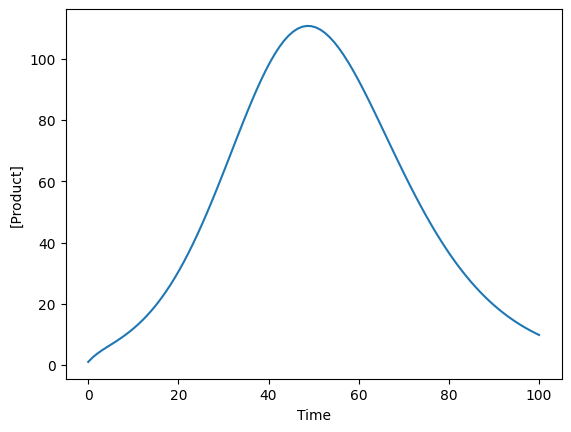

In [6]:
from autoreduce.utils import get_ODE
sys_ode = get_ODE(sys, timepoints_ode)
sol = sys_ode.solve_system().T
#try:
import matplotlib.pyplot as plt
plt.plot(timepoints_ode, np.transpose(np.array(C)@sol))
plt.xlabel('Time')
plt.ylabel('[Product]')
plt.show()


## Organizing the Reduced Models

The generated reduced models are stored and automatically assigned names so they can be evaluated and plotted individually.


In [7]:
all_reduced_models = list(results.keys())
reduced_models = all_reduced_models  # Backward-compatible alias

#automatically names them
for i, model in enumerate(reduced_models):
    globals()[f"reduced_model_{i+1}"] = model


## Comparing the Original and Reduced Models

Each reduced model is compared with the original infected-population output using mean absolute error (MAE). The legend is sorted from lowest to highest error, with green representing a closer match and red representing a larger difference.


In [8]:
from autoreduce.utils import get_ODE
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# Solve original full model
sys_ode = get_ODE(sys, timepoints_ode)
orig_sol = sys_ode.solve_system().T

# Original output: y = Cx
orig_output = np.ravel(np.array(C) @ orig_sol)

reduced_results = []

for i, model in enumerate(reduced_models):
    try:
        red_ode = get_ODE(model, timepoints_ode)
        red_sol = red_ode.solve_system().T

        # reduced output
        red_C = np.array(model.C)
        red_output = np.ravel(red_C @ red_sol)

        # compare to original
        mae = np.mean(np.abs(orig_output - red_output))

        reduced_results.append({
            "name": f"Reduced model {i+1}: {model.x}",
            "model": model,
            "output": red_output,
            "mae": mae
        })

    except Exception as e:
        print(f"Reduced model {i+1} failed: {model.x}")
        print(e)

# Sort best to worst
reduced_results = sorted(reduced_results, key=lambda d: d["mae"])

# Color by error
mae_values = [r["mae"] for r in reduced_results]

norm = plt.Normalize(min(mae_values), max(mae_values))
cmap = plt.cm.get_cmap("RdYlGn_r")  # green = closer, red = worse

fig = go.Figure()

# Original model as dotted black reference
fig.add_trace(
    go.Scatter(
        x=timepoints_ode,
        y=orig_output,
        mode="lines",
        name="Original full model",
        line=dict(color="black", dash="dot", width=4)
    )
)

# Add reduced models in sorted order
for r in reduced_results:
    rgba = cmap(norm(r["mae"]))
    color = (
        f"rgb({int(rgba[0]*255)},"
        f"{int(rgba[1]*255)},"
        f"{int(rgba[2]*255)})"
    )

    fig.add_trace(
        go.Scatter(
            x=timepoints_ode,
            y=r["output"],
            mode="lines",
            name=f"{r['name']} | MAE={r['mae']:.3g}",
            line=dict(color=color, width=2)
        )
    )

fig.update_layout(
    title="Original vs Reduced Protein Expression Models",
    xaxis_title="Time",
    yaxis_title="Protein X",
    legend_title="Models sorted by closeness",
    template="plotly_white",
    width=1000,
    height=650
)

fig.show()


C:\Users\angel\AppData\Local\Temp\ipykernel_16244\1150958932.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn_r")  # green = closer, red = worse


## Closest Reduced Models

Based on the infected-population comparison, reduced models 7, 19, 10, and 2 produced the closest results. Their retained states and reduced equations are displayed below.


In [9]:
selected_reduced_models = [
    ("7", reduced_model_7),
    ("19", reduced_model_19),
    ("10", reduced_model_2),
    ("2", reduced_model_2)
]

#automated printing out the title and function of the reduced model
from IPython.display import display, Math
from sympy import latex

#OG sys
display(Math(r"\text{Original System: } " + latex(sys.f)))

#redcced model function, states, & acutal function in LaTeX
for name, model in selected_reduced_models:
    print(f"Reduced Model {name}")
    print("States:", model.x)
    display(Math(r"\text{Reduced Model " + name + r": } " + latex(model.f)))
    print("-" * 60)


<IPython.core.display.Math object>

Reduced Model 7
States: [x0, x1, x2]


<IPython.core.display.Math object>

------------------------------------------------------------
Reduced Model 19
States: [x0, x1, x2, x5]


<IPython.core.display.Math object>

------------------------------------------------------------
Reduced Model 10
States: [x0, x2]


<IPython.core.display.Math object>

------------------------------------------------------------
Reduced Model 2
States: [x0, x2]


<IPython.core.display.Math object>

------------------------------------------------------------


## Error and Robustness

The following calculations combine approximation error and parameter sensitivity to evaluate the overall quality of a reduced model.


In [10]:
err = results[list(results.keys())[0]][0]
Se = results[list(results.keys())[0]][1]
weighted_se = 0
for p, Se_i in zip(params_values, Se):
    weighted_se += p*Se_i


In [11]:
d_R = weighted_se/err
d_R


np.float64(11848.939988960043)

In [12]:
w1 = 1
w2 = 1e-3
r = w1*err + w2*d_R
r


np.float64(650.1073129304234)

## Comparing Additional State Variables

The reduced models were originally evaluated using the infected population. However, the other SEIRVD variables can also be compared without running AutoReduce again.

For each variable, only reduced models that retained that state are included. Their solutions are compared with the corresponding full-model solution and ranked using MAE.


In [13]:
#code below automates switching variables to look at.
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from autoreduce.utils import get_ODE

# Names and axis labels for the six original SEIRVD states
state_information = {
    0: ("S", "Susceptible population"),
    1: ("E", "Exposed population"),
    2: ("I", "Infected population"),
    3: ("R", "Recovered population"),
    4: ("V", "Vaccinated population"),
    5: ("D", "Dead population"),
}

# Solve the original model once for use as the reference in every graph.
full_ode = get_ODE(sys, timepoints_ode)
full_solution = np.asarray(full_ode.solve_system().T, dtype=float)


def plot_reduced_models_for_state(state_index):
    """Plot one full-model state and every reduced model that retained it."""
    state_symbol = x[state_index]
    short_name, population_name = state_information[state_index]
    original_output = np.ravel(full_solution[state_index, :])
    compatible_results = []

    for model_number, model in enumerate(all_reduced_models, start=1):
        # Locate this original state within the reduced model's state list.
        matching_columns = [
            column
            for column, reduced_state in enumerate(model.x)
            if str(reduced_state) == str(state_symbol)
        ]

        # Skip models in which AutoReduce eliminated the selected state.
        if not matching_columns:
            continue

        try:
            reduced_ode = get_ODE(model, timepoints_ode)
            reduced_solution = np.asarray(
                reduced_ode.solve_system().T,
                dtype=float,
            )

            state_column = matching_columns[0]
            reduced_output = np.ravel(reduced_solution[state_column, :])

            if len(reduced_output) != len(original_output):
                raise ValueError(
                    "Original and reduced solutions have different lengths."
                )

            mae = np.mean(np.abs(original_output - reduced_output))

            compatible_results.append({
                "model_number": model_number,
                "states": model.x,
                "output": reduced_output,
                "mae": mae,
            })

        except Exception as error:
            print(
                f"Reduced model {model_number} failed for {short_name}: "
                f"{error}"
            )

    if not compatible_results:
        print(
            f"No solved reduced models retained "
            f"{short_name} = x[{state_index}]."
        )
        return []

    # Sort the compatible models from lowest to highest MAE.
    compatible_results.sort(key=lambda result: result["mae"])
    mae_values = [result["mae"] for result in compatible_results]
    minimum_mae = min(mae_values)
    maximum_mae = max(mae_values)

    if np.isclose(minimum_mae, maximum_mae):
        maximum_mae = minimum_mae + 1.0

    color_normalizer = plt.Normalize(minimum_mae, maximum_mae)
    color_map = plt.colormaps["RdYlGn_r"]

    figure = go.Figure()

    # Dotted black line: original full-model reference.
    figure.add_trace(go.Scatter(
        x=timepoints_ode,
        y=original_output,
        mode="lines",
        name=f"Original full model: {short_name}",
        line=dict(color="black", dash="dot", width=4),
    ))

    # Colored lines: compatible reduced models.
    for result in compatible_results:
        red, green, blue, _ = color_map(
            color_normalizer(result["mae"])
        )
        line_color = (
            f"rgb({int(red * 255)}, "
            f"{int(green * 255)}, "
            f"{int(blue * 255)})"
        )

        figure.add_trace(go.Scatter(
            x=timepoints_ode,
            y=result["output"],
            mode="lines",
            name=(
                f"Reduced model {result['model_number']}: "
                f"{result['states']} | MAE={result['mae']:.3g}"
            ),
            line=dict(color=line_color, width=2),
        ))

    figure.update_layout(
        title=(
            f"Original vs. Reduced SEIRVD Models: "
            f"{population_name} ({short_name})"
        ),
        xaxis_title="Time",
        yaxis_title=population_name,
        legend_title="Compatible models sorted by closeness",
        template="plotly_white",
        width=1000,
        height=650,
        hovermode="x unified",
    )

    figure.show()
    return compatible_results


## Susceptible Population ($S=x_0$)

The susceptible population represents people who are still at risk of infection. Tracking this group can help estimate whether an outbreak may continue and whether additional prevention measures are needed.


In [14]:
susceptible_results = plot_reduced_models_for_state(0)


## Exposed Population ($E=x_1$)

The exposed population includes people who have encountered the disease but are not yet actively infected. This variable can help predict future increases in infections after an incubation period.


In [15]:
exposed_results = plot_reduced_models_for_state(1)


## Recovered Population ($R=x_3$)

The recovered population represents people who have moved out of the infected group. Tracking this variable helps measure recovery and the cumulative effect of the outbreak.


In [16]:
recovered_results = plot_reduced_models_for_state(3)


## Vaccinated Population ($V=x_4$)

The vaccinated population represents people who leave the susceptible group through vaccination. This variable can be used to evaluate vaccination progress and its effect on disease transmission.


In [17]:
vaccinated_results = plot_reduced_models_for_state(4)


## Deceased Population ($D=x_5$)

The deceased population records cumulative deaths caused by the disease. Tracking this variable helps measure the severity and overall impact of the outbreak.


In [18]:
deceased_results = plot_reduced_models_for_state(5)
